### Preamble

In [ ]:
# try:
#     import pgmuvi
# except (ImportError, ModuleNotFoundError):
#     %pip install -q git+https://github.com/ICSM/pgmuvi.git
#     import pgmuvi

In [1]:
!git config --global user.email "s.srinivasan@irya.unam.mx"
!git config --global user.name "Sundar Srinivasan"
!git clone https://github.com/ICSM/pgmuvi.git pgmuvi
%cd pgmuvi
!git checkout -b test-combined main
!git merge --no-edit origin/copilot/fix-peak-ranking-logic
!git merge --no-edit origin/copilot/modify-x-axis-limits-centering
!git merge --no-edit origin/copilot/redesign-select-bands-method
!git merge --no-edit origin/copilot/implement-drop-bands-method
!git merge --no-edit origin/copilot/add-merge-and-concat-methods
!git merge --no-edit origin/copilot/check-psd-panels-log-scale
!git merge --no-edit origin/copilot/add-lightcurve-to-csv-method
!git merge --no-edit origin/copilot/add-band-attribute-to-lightcurve-again
!git merge --no-edit origin/copilot/fix-stetson-threshold-logic
!git merge --no-edit origin/copilot/fix-lightcurve-merge-band-attribute
# !git merge --no-edit origin/copilot/check-band-data-validation
!pip install -q -e .

Cloning into 'pgmuvi'...
remote: Enumerating objects: 3547, done.
remote: Counting objects: 100% (1102/1102), done.
remote: Compressing objects: 100% (296/296), done.
remote: Total 3547 (delta 1002), reused 844 (delta 806), pack-reused 2445 (from 1)
Receiving objects: 100% (3547/3547), 4.04 MiB | 15.22 MiB/s, done.
Resolving deltas: 100% (2522/2522), done.
/content/pgmuvi
Switched to a new branch 'test-combined'
Auto-merging pgmuvi/lightcurve.py
Merge made by the 'ort' strategy.
 pgmuvi/lightcurve.py                | 211 +++++++++--
 tests/test_peak_ranking_physical.py | 712 ++++++++++++++++++++++++++++++++++++
 tests/test_period_summary.py        |  25 +-
 tests/test_period_summary_peaks.py  |  28 +-
 4 files changed, 932 insertions(+), 44 deletions(-)
 create mode 100644 tests/test_peak_ranking_physical.py
Auto-merging pgmuvi/lightcurve.py
Merge made by the 'ort' strategy.
 pgmuvi/lightcurve.py         | 28 +++++++++++------
 tests/test_2d_integration.py | 72 ++++++++++++++++++++++++

In [25]:
# Imports and seeds for reproducibility
import gpytorch
from gpytorch.likelihoods import FixedNoiseGaussianLikelihood

seed = 0
import torch
torch.manual_seed(seed)

import numpy as np
np.random.seed(seed)

import random
random.seed(seed)

from pgmuvi.lightcurve import Lightcurve
from gpytorch.constraints import Interval
import pgmuvi.gps as gps
from pgmuvi import synthetic
from pgmuvi.preprocess import subsample_lightcurve

import matplotlib.pyplot as plt

SEED = 0
TRAINING_ITER = 1000
DTYPE = torch.float64
DEVICE = torch.device("cpu")

## Purpose of this notebook

This notebook discusses the `fit_LS()` method implemented in the `Lightcurve` class in PGMUVI and demonstrates how to use it for Lomb--Scargle period analysis of astronomical light curves.

In PGMUVI, `fit_LS()` is primarily useful as a fast diagnostic and exploratory tool. It can be used to:

- identify candidate periodicities in a light curve,
- inspect the full Lomb--Scargle periodogram,
- compare the strongest peaks in the frequency domain,
- provide initial guidance before fitting more flexible Gaussian-process models.

This notebook focuses specifically on how `fit_LS()` behaves in the current PGMUVI codebase, rather than on Lomb--Scargle analysis in the abstract. In particular, we will examine:

- how the method behaves for 1D and multiband light curves,
- what the different return modes mean,
- how significance flags are computed,
- and what practical caveats arise when interpreting the output.

A central theme of this notebook is that Lomb--Scargle in PGMUVI should usually be treated as a useful diagnostic and initialization step, not as the final word on the physically correct period in difficult or irregularly sampled cases.

## Where `fit_LS()` sits in the PGMUVI workflow

The `fit_LS()` method is part of the `Lightcurve` class and operates directly on the time-series data stored within it. Depending on how the `Lightcurve` object is constructed, this can represent:

- a single-band (1D) light curve, or  
- a multiband (2D) light curve with multiple wavelengths or bands.

The role of `fit_LS()` within the broader PGMUVI workflow is intentionally limited but important:

- It provides a **fast, non-parametric estimate** of periodic structure in the data.
- It can be used to **identify candidate frequencies** before fitting more flexible models.
- It helps **diagnose sampling limitations**, aliasing, and noise-dominated regimes.
- It is often used to **initialize or guide Gaussian-process (GP) models**, especially those with spectral-mixture or periodic structure.

### Return modes of `fit_LS()`

The behavior of `fit_LS()` depends on the keyword arguments used. There are three practically relevant modes:

1. **Full periodogram mode**
   
   - `freq_only=True`
   - Returns:
     - frequency grid
     - power evaluated at each frequency

   This is the mode to use when you want to **inspect or plot the full Lomb--Scargle periodogram**.

2. **Peak summary mode (default)**
   
   - `freq_only=False`, `return_full=False`
   - Returns:
     - peak frequencies (ordered by decreasing power)
     - boolean significance flags for each peak

   This is the mode to use when you only care about the **strongest candidate periodicities**.

3. **Combined mode**
   
   - `freq_only=False`, `return_full=True`
   - Returns:
     - peak frequencies
     - significance flags
     - full frequency grid
     - full power array

   This is the most complete mode and is useful when you want **both a summary and the full periodogram** in a single call.

### Key points to keep in mind

- The method works in **frequency space**, not period space. Any interpretation in terms of periods requires converting frequency → period.
- Peaks are returned in **descending order of power**, not by frequency or period.
- The meaning of the **significance flags differs between 1D and multiband cases**, and will be discussed later.

In the following sections, we will demonstrate these modes in practice, starting with a simple 1D example.

## Basic 1D example

We begin with a simple synthetic example for which the true period is known. The synthetic generator in `synthetic.py` produces a multiband light curve, but for this first demonstration we will extract a single band and treat it as a 1D light curve.

This lets us study the basic behavior of `fit_LS()` in the simplest possible setting before moving on to multiband use.

In this section we will:

- extract one band from the synthetic light curve,
- compute the full Lomb--Scargle periodogram,
- convert frequency to period,
- and visualize the resulting power spectrum.

For this mono-periodic example, the injected period is 150 d.

In [30]:
"""Generate a set of mono-periodic light curves using synthetic.py"""

n_per_band = (25, 40)  # number of data points per light curve limited to this range

SINGLE_DATASET_CONFIG = dict(
    period=150,
    t_span=150 * 2.3,
    n_per_band=n_per_band,
    wavelengths=[0.8, 1.2, 2.2],  # wavelengths in µm
    amplitude_law="extinction",
    seed=SEED,
)

lc2d_synth_1comp = synthetic.make_chromatic_sinusoid_2d(**SINGLE_DATASET_CONFIG)

# ------------------------------------------------------------------
# Ensure 'band' attribute exists (synthetic generator does not set it)
# ------------------------------------------------------------------
# wavelengths = lc2d_synth_1comp.xdata[:, 1]
wavelengths = np.asarray(lc2d_synth_1comp.xdata[:, 1], dtype=float)

unique_waves = np.unique(wavelengths)

# Map each wavelength to a string band label
wave_to_band = {w: str(i) for i, w in enumerate(unique_waves)}

band = np.array([f"band {wave_to_band[w]}" for w in wavelengths], dtype=object)
lc2d_synth_1comp.band = band

Note: PGMUVI does not currently provide a built-in plotting utility for Lomb--Scargle periodograms. The user is expected to retrieve the frequency grid and power using `fit_LS(freq_only=True)` and construct plots manually.

Available bands: ['band 0' 'band 1' 'band 2']
Selected band: band 0
Number of points in 1D light curve: 38


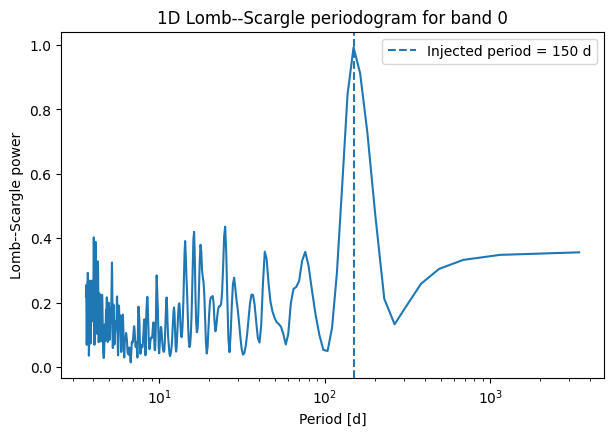

In [31]:
# Use one band from the synthetic mono-periodic 2D light curve as a 1D example
lc2d = lc2d_synth_1comp

# Inspect available band labels
bands = np.unique(lc2d.band)
print("Available bands:", bands)

# Extract the first band as a 1D light curve
band0 = bands[0]
lc1d = lc2d.select_bands([band0])

print(f"Selected band: {band0}")
print(f"Number of points in 1D light curve: {len(lc1d.xdata)}")

# Compute the full Lomb--Scargle periodogram
freq, power = lc1d.fit_LS(freq_only=True)

# Convert frequency grid to period
period = 1.0 / freq

# Sort by period for plotting
idx = np.argsort(period)
period_sorted = period[idx]
power_sorted = power[idx]

# Plot Lomb--Scargle power as a function of period
plt.figure(figsize=(7, 4.5))
plt.plot(period_sorted, power_sorted)
plt.axvline(150.0, linestyle="--", label="Injected period = 150 d")
plt.xscale("log")
plt.xlabel("Period [d]")
plt.ylabel("Lomb--Scargle power")
plt.title(f"1D Lomb--Scargle periodogram for {band0}")
plt.legend()
plt.show()

## Extracting the strongest peaks

The previous example used `freq_only=True`, which returns the full frequency grid and the corresponding Lomb--Scargle power. That is useful for plotting the periodogram.

Often, however, we only want a compact summary of the strongest candidate periodicities. In that case, we use the default summary mode:

- `freq_only=False`
- `return_full=False`

In this mode, `fit_LS()` returns:

- the frequencies of the strongest detected peaks, ordered by decreasing power,
- and a boolean mask indicating which of those peaks are considered significant.

Since `fit_LS()` works in frequency space, we will explicitly convert the returned peak frequencies to periods before interpreting them.

In [32]:
# Extract the strongest Lomb--Scargle peaks from the same 1D light curve
peak_freqs, signif_mask = lc1d.fit_LS(
    freq_only=False,
    num_peaks=5,
    return_full=False,
)

peak_periods = 1.0 / peak_freqs

print("Strongest detected peaks:")
for i, (f, p, is_sig) in enumerate(zip(peak_freqs, peak_periods, signif_mask), start=1):
    print(
        f"Peak {i}: "
        f"frequency = {float(f):.6f}, "
        f"period = {float(p):.3f} d, "
        f"significant = {bool(is_sig)}"
    )

print("\nInjected period = 150.0 d")

Strongest detected peaks:
Peak 1: frequency = 0.006704, period = 149.171 d, significant = True
Peak 2: frequency = 0.039931, period = 25.043 d, significant = False
Peak 3: frequency = 0.061499, period = 16.260 d, significant = False
Peak 4: frequency = 0.248038, period = 4.032 d, significant = False
Peak 5: frequency = 0.069660, period = 14.355 d, significant = False

Injected period = 150.0 d


## Returning both the peak summary and the full periodogram

In some situations, we want both views of the Lomb--Scargle result at once:

- a compact summary of the strongest peaks, and
- the full frequency grid and periodogram power for plotting or further analysis.

For that, `fit_LS()` provides the option:

- `freq_only=False`
- `return_full=True`

In this mode, the method returns four objects:

1. the frequencies of the strongest peaks,
2. a boolean mask indicating which of those peaks are significant,
3. the full frequency grid,
4. and the full Lomb--Scargle power evaluated on that grid.

This can be convenient because it avoids having to call `fit_LS()` twice when both the peak summary and the full periodogram are needed.

In [33]:
# Return both the peak summary and the full periodogram
peak_freqs_full, signif_mask_full, freq_full, power_full = lc1d.fit_LS(
    freq_only=False,
    num_peaks=5,
    return_full=True,
)

peak_periods_full = 1.0 / peak_freqs_full
period_full = 1.0 / freq_full

print("Peak summary from combined return mode:")
for i, (f, p, is_sig) in enumerate(
    zip(peak_freqs_full, peak_periods_full, signif_mask_full),
    start=1,
):
    print(
        f"Peak {i}: "
        f"frequency = {float(f):.6f}, "
        f"period = {float(p):.3f} d, "
        f"significant = {bool(is_sig)}"
    )

print(f"\nLength of full frequency grid: {len(freq_full)}")
print(f"Length of full power array:    {len(power_full)}")

Peak summary from combined return mode:
Peak 1: frequency = 0.006704, period = 149.171 d, significant = True
Peak 2: frequency = 0.039931, period = 25.043 d, significant = False
Peak 3: frequency = 0.061499, period = 16.260 d, significant = False
Peak 4: frequency = 0.248038, period = 4.032 d, significant = False
Peak 5: frequency = 0.069660, period = 14.355 d, significant = False

Length of full frequency grid: 475
Length of full power array:    475


## How to interpret the outputs

Before moving on to more complex cases, it is important to be precise about what `fit_LS()` actually returns and how those outputs should be interpreted.

### Frequencies vs periods

All outputs from `fit_LS()` are in **frequency space**. This means:

- the returned peak values are frequencies,
- the period must always be computed explicitly as:

  period = 1 / frequency

Any scientific interpretation (e.g., comparing with expected pulsation timescales) should be done in period space, not frequency space.

### Ordering of peaks

The returned peaks are:

- ordered by **decreasing Lomb--Scargle power**,
- not by frequency or period.

This is important because:

- the first peak is simply the strongest in the periodogram,
- it is not guaranteed to correspond to the physically correct period.

### Meaning of the significance mask

The boolean array returned alongside the peak frequencies indicates whether each peak passes an internal significance criterion.

However:

- this is **not a direct p-value**,  
- it is the result of a thresholding procedure applied to the Lomb--Scargle false-alarm probabilities.

In particular:

- significance is determined differently for single-band and multiband cases,
- and should be treated as a **heuristic filter**, not a definitive statistical decision.

### Practical takeaway

- Always convert frequencies to periods before interpretation.
- Do not assume that the top-ranked peak is physically correct.
- Treat the significance mask as a guide, not a guarantee.

In the following sections, we will explore how these issues become more pronounced in multiband data and in realistic sampling conditions.

## Multiband Lomb--Scargle in PGMUVI

So far, we have treated a single band extracted from a multiband light curve. However, `fit_LS()` can operate directly on the full multiband dataset.

In this case:

- the input light curve contains multiple bands (stored via the `band` attribute),
- the method uses a multiband Lomb--Scargle implementation internally,
- and all bands are analyzed simultaneously.

This is not equivalent to running Lomb--Scargle independently on each band. Instead, the method attempts to infer a shared periodic signal across bands, while allowing for differences in sampling and amplitude.

This can be advantageous when:

- individual bands are sparsely sampled,
- or when the signal is present across multiple wavelengths but is weak in any one band.

In this section, we will:

- run `fit_LS()` directly on the full multiband light curve,
- inspect the resulting periodogram,
- and compare it with the single-band result from earlier.

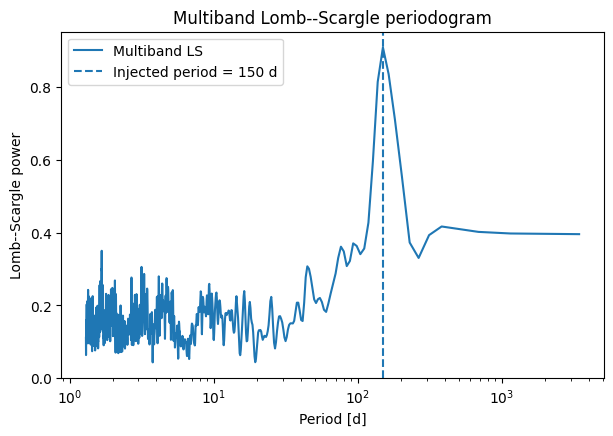

In [34]:
# Run Lomb–Scargle directly on the full multiband light curve
lc2d = lc2d_synth_1comp

# Compute full multiband periodogram
freq_mb, power_mb = lc2d.fit_LS(freq_only=True)

# Convert to period
period_mb = 1.0 / freq_mb

# Sort for plotting
idx = np.argsort(period_mb)
period_mb_sorted = period_mb[idx]
power_mb_sorted = power_mb[idx]

# Plot multiband periodogram
plt.figure(figsize=(7, 4.5))
plt.plot(period_mb_sorted, power_mb_sorted, label="Multiband LS")
plt.axvline(150.0, linestyle="--", label="Injected period = 150 d")
plt.xscale("log")
plt.xlabel("Period [d]")
plt.ylabel("Lomb--Scargle power")
plt.title("Multiband Lomb--Scargle periodogram")
plt.legend()
plt.show()

## How multiband Lomb--Scargle differs from single-band analysis

At first glance, applying `fit_LS()` to a multiband light curve may seem like a straightforward extension of the single-band case. In practice, there are several important differences that affect both the results and their interpretation.

### Joint analysis across bands

In the multiband case:

- all bands are analyzed simultaneously,
- the method attempts to identify a **shared periodic signal**,
- rather than treating each band independently.

This means that:

- information from well-sampled bands can help constrain poorly sampled ones,
- but inconsistencies between bands can also broaden or shift the detected peaks.

### Sensitivity to heterogeneous sampling

A key issue in multiband datasets is that different bands often have:

- different numbers of observations,
- different time coverage,
- and different noise levels.

As a result:

- the effective sensitivity of the periodogram can be dominated by one or two bands,
- and the resulting peak structure may not reflect all bands equally.

This is particularly important in PGMUVI, where multiband light curves are often constructed from heterogeneous surveys.

### Interpretation of peaks

Compared to the 1D case:

- peaks in the multiband periodogram may be broader,
- multiple nearby peaks may appear due to competing constraints across bands,
- and the highest peak is not necessarily the most physically meaningful solution.

### Significance in the multiband case

The significance flags returned by `fit_LS()`:

- are computed differently in the multiband case,
- and should be interpreted with additional caution.

In particular:

- they do not fully capture inter-band inconsistencies,
- and should not be treated as definitive evidence for or against a periodic signal.

### Practical takeaway

When working with multiband data:

- always compare multiband results with single-band results,
- inspect multiple peaks, not just the top one,
- and consider the sampling properties of each band.

In the next section, we will examine one specific option that can strongly affect multiband results: `use_best_band_init`.

## Effect of `use_best_band_init` on the frequency grid

One subtle but important option in `fit_LS()` is:

    use_best_band_init=True

This affects how the frequency grid is constructed in the multiband case.

### Why this matters

The Lomb--Scargle periodogram is evaluated on a grid of frequencies. In multiband data, this grid must be chosen based on the sampling properties of the data.

By default:

- the frequency grid is determined using the combined dataset,
- which may include sparsely sampled bands.

However, if one band is significantly better sampled than the others, this default choice can:

- reduce the effective resolution of the grid,
- or bias the search toward the characteristics of the combined sampling rather than the best band.

### What `use_best_band_init=True` does

When this option is enabled:

- the frequency grid is derived from the **best-sampled band**,
- and then applied to the full multiband dataset.

This can improve:

- frequency resolution,
- peak sharpness,
- and recovery of the true underlying period.

### When to use it

This option is particularly useful when:

- one band clearly dominates in terms of sampling quality,
- or when multiband results appear smeared or poorly resolved.

In the example below, we compare the multiband periodogram with and without this option.

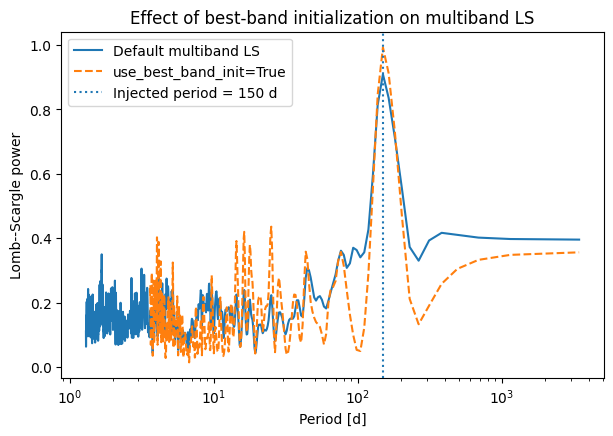

In [35]:
# Compare multiband LS with and without use_best_band_init

lc2d = lc2d_synth_1comp

# Default multiband LS
freq_default, power_default = lc2d.fit_LS(freq_only=True)

# Best-band-initialized multiband LS
freq_best, power_best = lc2d.fit_LS(
    freq_only=True,
    use_best_band_init=True,
)

# Convert to periods
period_default = 1.0 / freq_default
period_best = 1.0 / freq_best

# Sort for plotting
idx_def = np.argsort(period_default)
idx_best = np.argsort(period_best)

period_default = period_default[idx_def]
power_default = power_default[idx_def]

period_best = period_best[idx_best]
power_best = power_best[idx_best]

# Plot comparison
plt.figure(figsize=(7, 4.5))
plt.plot(period_default, power_default, label="Default multiband LS")
plt.plot(period_best, power_best, linestyle="--", label="use_best_band_init=True")

plt.axvline(150.0, linestyle=":", label="Injected period = 150 d")

plt.xscale("log")
plt.xlabel("Period [d]")
plt.ylabel("Lomb--Scargle power")
plt.title("Effect of best-band initialization on multiband LS")
plt.legend()
plt.show()

## Quantitative comparison of periodogram peaks

The visual comparison above suggests that `use_best_band_init=True` produces a sharper and higher peak at the true period.

To make this precise, we can compare:

- **peak height**: the maximum Lomb--Scargle power.  
  This measures how strong the detected signal is relative to the noise background.

- **peak prominence**: how distinct the peak is relative to its surroundings.  
  A peak with high prominence stands clearly above neighboring structure, while a low-prominence peak may be part of a broader plateau or contaminated by nearby competing frequencies. This is especially important in irregularly sampled data where aliases and side lobes can appear.

- **area fraction**: how concentrated the total power is around the peak.  
  This measures the fraction of the total periodogram power contained within a window around the peak. A high area fraction indicates a well-localized, coherent signal, whereas a low value suggests that the power is spread over a wide range of frequencies, which can indicate poor constraint, multiple competing solutions, or long-timescale structure.

These metrics help quantify whether a detected period is:

- sharply localized (high coherence),
- or broad and diffuse (low coherence / possible artifacts).

In the following cell, we compute these quantities for both configurations.

In [41]:
# Quantitative comparison of peak properties

from scipy.signal import find_peaks, peak_prominences
from scipy.integrate import trapezoid as trapz

def compute_peak_metrics(period, power):
    # Identify peaks
    peaks, _ = find_peaks(power)

    if len(peaks) == 0:
        return None

    # Take the highest peak
    peak_idx = peaks[np.argmax(power[peaks])]

    peak_height = power[peak_idx]

    # Prominence
    prominences = peak_prominences(power, peaks)[0]
    peak_prominence = prominences[np.argmax(power[peaks])]

    # Area fraction: integrate power in a window around the peak
    # Define a window of ±10% in period space
    p0 = period[peak_idx]
    mask = (period > 0.9 * p0) & (period < 1.1 * p0)

    area_peak = trapz(power[mask], period[mask])
    area_total = trapz(power, period)

    area_fraction = area_peak / area_total if area_total > 0 else np.nan

    return {
        "peak_period": p0,
        "peak_height": peak_height,
        "peak_prominence": peak_prominence,
        "area_fraction": area_fraction,
    }

# Compute metrics
metrics_default = compute_peak_metrics(period_default, power_default)
metrics_best = compute_peak_metrics(period_best, power_best)

print("Default multiband LS:")
for k, v in metrics_default.items():
    print(f"  {k}: {float(v):.6f}")

print("\nuse_best_band_init=True:")
for k, v in metrics_best.items():
    print(f"  {k}: {float(v):.6f}")

Default multiband LS:
  peak_period: 149.170715
  peak_height: 0.909449
  peak_prominence: 0.579050
  area_fraction: 0.016485

use_best_band_init=True:
  peak_period: 149.170715
  peak_height: 0.992789
  peak_prominence: 0.859738
  area_fraction: 0.020845


## Interpreting the quantitative comparison

These results support the visual impression from the previous figure.

Both configurations recover essentially the same peak period, about 149.17 d, which is close to the injected 150 d period. The main difference is therefore not the location of the peak, but how clearly and how strongly that peak is represented in the periodogram.

In this example, `use_best_band_init=True` gives:

- a higher **peak height**,
- a higher **peak prominence**,
- and a higher **area fraction**.

Taken together, this indicates that the signal is not merely detected at the correct period, but is also more sharply localized and more distinct from surrounding structure when the frequency grid is initialized from the best-sampled band. In other words, the periodogram is cleaner and less smeared in the neighborhood of the true solution.

However, this does **not** mean that `use_best_band_init=True` should always be expected to perform better.

The reason is that this option assumes that the best-sampled band provides the most useful frequency-grid initialization for the full multiband problem. That will often be a good assumption, but not always. Situations that can deviate from this expectation include:

- cases where the best-sampled band is also the noisiest band,
- cases where that band contains systematics or artifacts not present in the other bands,
- cases where another band has fewer points but a much cleaner periodic signal,
- or cases where all bands are already sampled similarly well, so that using the best band provides little practical advantage.

In such situations, `use_best_band_init=True` can produce little improvement, or in some cases even emphasize a suboptimal part of frequency space.

The practical lesson is that `use_best_band_init=True` should be treated as a useful option to test, not as a universally superior setting. In well-behaved heterogeneous datasets such as the present synthetic example, it can sharpen the recovery of the true period. But its effect should always be judged from the resulting periodogram and, when possible, from quantitative diagnostics such as those computed above.

## Two-component multiband example

So far, we have worked with a mono-periodic light curve. In realistic applications, light curves often contain multiple periodic components.

In this section, we generate a synthetic multiband light curve with:

- two periodic components,
- different amplitudes,
- and a phase offset between them.

This provides a more realistic test of `fit_LS()`, since:

- multiple peaks should appear in the periodogram,
- the strongest peak may not correspond to the dominant physical component in all bands,
- and peak structure can become more complex due to interference between components.

We will:

- generate the two-component synthetic dataset,
- run Lomb--Scargle on the full multiband light curve,
- and inspect how the multiple periods are recovered.

In [42]:
"""Generate a set of light curves with two period components and a phase lag"""

n_per_band = (25, 40)  # number of data points per light curve limited to this range

MULTI_DATASET_CONFIG = dict(
    components=[
        {"period": 150.0, "amplitude_fraction": 1.0, "phase": 0.0},
        {"period": 66.0, "amplitude_fraction": 0.3, "phase": np.pi / 2 * 0.85},
    ],
    t_span=150 * 2.3,
    n_per_band=n_per_band,
    wavelengths=[0.8, 1.2, 2.2],
    amplitude_law="extinction",
    noise_level=0.05,
    seed=SEED,
)

lc2d_synth_2comp = synthetic.make_multi_sinusoid_chromatic_2d(**MULTI_DATASET_CONFIG)

# ------------------------------------------------------------------
# Ensure 'band' attribute exists (same logic as before)
# ------------------------------------------------------------------
wavelengths = np.asarray(lc2d_synth_2comp.xdata[:, 1], dtype=float)

unique_waves = np.unique(wavelengths)
wave_to_band = {w: str(i) for i, w in enumerate(unique_waves)}

band = np.array([f"band {wave_to_band[w]}" for w in wavelengths], dtype=object)

lc2d_synth_2comp.band = band

In [51]:
gus = lc2d_synth_2comp.merge(lc_HS)

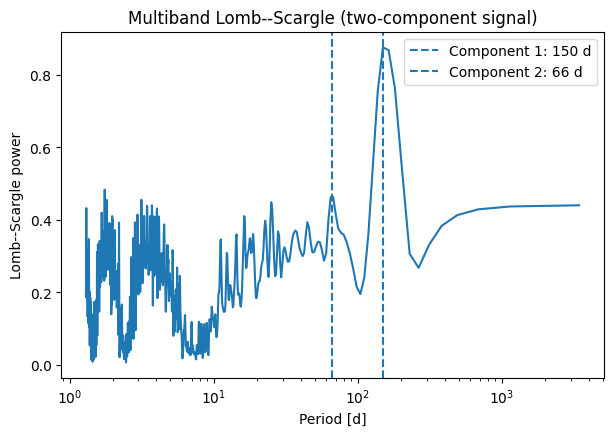

In [43]:
# Run multiband Lomb–Scargle on the two-component dataset

freq_2c, power_2c = lc2d_synth_2comp.fit_LS(freq_only=True)

period_2c = 1.0 / freq_2c

# Sort for plotting
idx = np.argsort(period_2c)
period_2c = period_2c[idx]
power_2c = power_2c[idx]

# Plot
plt.figure(figsize=(7, 4.5))
plt.plot(period_2c, power_2c)

plt.axvline(150.0, linestyle="--", label="Component 1: 150 d")
plt.axvline(66.0, linestyle="--", label="Component 2: 66 d")

plt.xscale("log")
plt.xlabel("Period [d]")
plt.ylabel("Lomb--Scargle power")
plt.title("Multiband Lomb--Scargle (two-component signal)")
plt.legend()
plt.show()

## Comparing the two-component case with and without `use_best_band_init`

In the two-component case, the choice of frequency-grid initialization can affect more than just the appearance of the dominant peak.

In particular, it can influence:

- how sharply each component is localized,
- how clearly the secondary peak is separated from surrounding structure,
- and how much low-level complexity appears between or around the true periods.

As before, we therefore compare the multiband Lomb--Scargle periodogram obtained:

- with the default initialization, and
- with `use_best_band_init=True`.

For a multi-component signal, this comparison is especially useful because a visually modest change in periodogram structure can still matter for identifying weaker secondary periodicities.

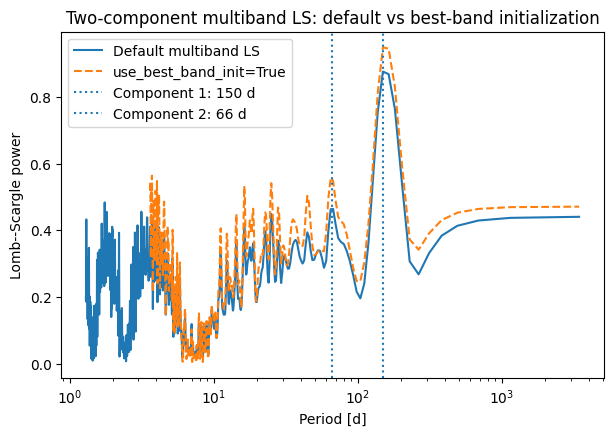

In [46]:
# Compare the two-component multiband LS periodogram
# with and without use_best_band_init

lc2d = lc2d_synth_2comp

# Default multiband LS
freq_2c_default, power_2c_default = lc2d.fit_LS(freq_only=True)

# Best-band-initialized multiband LS
freq_2c_best, power_2c_best = lc2d.fit_LS(
    freq_only=True,
    use_best_band_init=True,
)

# Convert to periods
period_2c_default = 1.0 / freq_2c_default
period_2c_best = 1.0 / freq_2c_best

# Sort for plotting
idx_def = np.argsort(period_2c_default)
idx_best = np.argsort(period_2c_best)

period_2c_default = period_2c_default[idx_def]
power_2c_default = power_2c_default[idx_def]

period_2c_best = period_2c_best[idx_best]
power_2c_best = power_2c_best[idx_best]

# Plot comparison
plt.figure(figsize=(7, 4.5))
plt.plot(period_2c_default, power_2c_default, label="Default multiband LS")
plt.plot(period_2c_best, power_2c_best, linestyle="--", label="use_best_band_init=True")

plt.axvline(150.0, linestyle=":", label="Component 1: 150 d")
plt.axvline(66.0, linestyle=":", label="Component 2: 66 d")

plt.xscale("log")
plt.xlabel("Period [d]")
plt.ylabel("Lomb--Scargle power")
plt.title("Two-component multiband LS: default vs best-band initialization")
plt.legend()
plt.show()

## Interpreting the two-component comparison

In this example, the effect of `use_best_band_init=True` is not uniform across the periodogram.

For the dominant component near 150 d:

- the peak is slightly higher,
- and somewhat more sharply defined,

which is consistent with the mono-periodic case and indicates improved localization of the strongest signal.

However, the behavior of the secondary component near 66 d is more revealing.

- The secondary peak is present in both configurations,
- but it is not significantly sharper or more isolated when using `use_best_band_init=True`.

This indicates that, in this case, improving the frequency-grid initialization primarily benefits the dominant component, while the weaker component remains limited by noise, sampling, and its lower amplitude.

In addition, the short-period region shows increased small-scale structure when `use_best_band_init=True`. This behavior can be understood in terms of the sampling properties of the data. When this option is enabled, the frequency grid is determined by the best-sampled band. This band typically has a higher effective Nyquist frequency and supports finer resolution in frequency space due to its denser cadence.
However, this finer grid is then applied to the full multiband dataset, which may include bands with significantly poorer sampling. These bands do not reliably constrain such high frequencies. As a result, the periodogram is evaluated in a regime where the data provide weak or no constraint, leading to amplified noise and spurious structure at short periods. This effect can be diagnosed by comparing sampling metrics computed for:
- the full multiband light curve, and  
- the best-sampled band alone.

In cases where the best band supports much higher frequencies than the combined dataset, `use_best_band_init=True` effectively over-resolves the periodogram in regions that are not physically constrained by the data, producing the kind of small-scale structure seen here.

Taken together, this example illustrates an important point:

- `use_best_band_init=True` can improve the localization of the strongest periodic signal,
- but it does not guarantee improved recovery of weaker components,
- and it may introduce additional structure in poorly constrained regions.

This reinforces the idea that this option should be evaluated based on the specific scientific goal—particularly whether the priority is accurate localization of the dominant period or reliable identification of multiple components.

## Comparing sampling metrics for the multiband light curve and the best band

To understand why `use_best_band_init=True` can sharpen the dominant peak while also introducing extra short-period structure, it is useful to compare the sampling properties of:

- the full multiband light curve, and
- the best-sampled band by itself.

The key point is that `use_best_band_init=True` builds the frequency grid from the best band, not from the combined multiband sampling. If that best band supports a finer cadence and therefore a higher effective Nyquist frequency than the full dataset as a whole, then the resulting grid may probe short-period structure that the other bands do not constrain well.

In the cell below, we compute and print the sampling metrics for:

- the full multiband light curve, and
- the single-band light curve corresponding to the best band.

We will pay particular attention to:

- `n_points`
- `baseline`
- `median_cadence`
- `nyquist_period`
- `nyquist_frequency`
- `longest_detectable_period`
- `max_gap_fraction`
- `sampling_uniformity`

These quantities help explain whether the best-band frequency grid is only modestly finer than the combined sampling, or whether it is fine enough to over-resolve poorly constrained regions of the multiband periodogram.

In [47]:
# Compare sampling metrics for:
#   (1) the full multiband light curve
#   (2) the best-sampled band alone

lc2d = lc2d_synth_2comp

# Metrics for the full multiband light curve
metrics_full = lc2d.compute_sampling_metrics()

# Find the best band as the band with the largest number of points
bands = np.unique(lc2d.band)
band_counts = {band: int(np.sum(lc2d.band == band)) for band in bands}
best_band = max(band_counts, key=band_counts.get)

lc_best = lc2d.select_bands([best_band])
metrics_best = lc_best.compute_sampling_metrics()

print(f"Best band selected: {best_band}")
print(f"Band counts: {band_counts}")

keys_to_show = [
    "n_points",
    "baseline",
    "median_cadence",
    "mean_cadence",
    "cadence_std",
    "nyquist_period",
    "nyquist_frequency",
    "longest_detectable_period",
    "max_gap_fraction",
    "duty_cycle",
    "sampling_uniformity",
]

print("\nSampling metrics: full multiband light curve")
for key in keys_to_show:
    value = metrics_full.get(key, None)
    if isinstance(value, (int, np.integer)):
        print(f"  {key}: {value}")
    elif isinstance(value, (float, np.floating)):
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: {value}")

print("\nSampling metrics: best band only")
for key in keys_to_show:
    value = metrics_best.get(key, None)
    if isinstance(value, (int, np.integer)):
        print(f"  {key}: {value}")
    elif isinstance(value, (float, np.floating)):
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: {value}")

Best band selected: band 0
Band counts: {'band 0': 38, 'band 1': 35, 'band 2': 33}

Sampling metrics: full multiband light curve
  n_points: 106
  baseline: 343.092621
  median_cadence: 2.389172
  mean_cadence: 3.267549
  cadence_std: 3.688903
  nyquist_period: 4.778343
  nyquist_frequency: 0.209278
  longest_detectable_period: 171.546310
  max_gap_fraction: 0.063361
  duty_cycle: 0.738145
  sampling_uniformity: 0.000000

Sampling metrics: best band only
  n_points: 38
  baseline: 343.092621
  median_cadence: 5.649231
  mean_cadence: 9.272775
  cadence_std: 9.400241
  nyquist_period: 11.298462
  nyquist_frequency: 0.088508
  longest_detectable_period: 171.546310
  max_gap_fraction: 0.124746
  duty_cycle: 0.625693
  sampling_uniformity: 0.000000


## How to interpret these sampling metrics

The comparison above shows that, in this example, the best-sampled band is not actually the one with the finest cadence.

In particular:

- the multiband light curve has a smaller `median_cadence`,
- a smaller `nyquist_period`,
- and therefore a higher `nyquist_frequency` than the best band alone.

This means that the combined multiband dataset supports higher frequencies (shorter periods) than the best band does individually.

As a result, when `use_best_band_init=True` is used, the frequency grid is derived from a band that has *coarser* sampling and a lower effective Nyquist frequency than the full dataset. This does not increase the resolution of the periodogram. Instead, it changes the grid in a way that is less well matched to the combined sampling.

This helps explain the behavior seen in the periodogram:

- the dominant peak near 150 d becomes slightly sharper, likely because the grid is better aligned with the structure of that signal in the best band,
- but the short-period region shows increased small-scale structure, not because of over-resolution, but because the frequency grid is derived from a sparser and less stable sampling pattern.

In other words, the grid inherited from the best band is not optimal for representing the joint constraints of the full dataset. This leads to noisier behavior in regions where the signal is weak and the sampling is already limiting.

This example highlights an important point:

- `use_best_band_init=True` does not necessarily select the band with the finest cadence,
- and it does not guarantee a better frequency grid for the full multiband dataset,
- even if it improves the appearance of the dominant peak.

The effect of this option therefore depends on the detailed sampling properties of both the individual bands and the combined dataset, and should always be evaluated empirically.